# Example of Basic Beam Acceleration

Import all blond features for later use.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from blond import (
    Beam,
    BeamObservationOncePerTurn,
    DriftSimple,
    MagneticCyclePerTurn,
    RFStationPhaseObservation,
    Ring,
    Simulation,
    SingleHarmonicRFStation,
    momentum_compaction_factor,
    proton,
    backend,
)
from blond.experimental import (
    SemiEmpiricMatcher,
)
from blond.testing import pytest_active

# When testing, some variables migh be changed for performace..
pytest_is_active = pytest_active()

Using environment variable BLOND_BACKEND_MODE = python
Changing backend to `Numpy64Bit`


/home/slauber/PycharmProjects/deleteme/blonder/blond/experimental/__init__.py:34: ExperimentalFeaturesWarning: 
Importing experimental features. These are under development and are
liable to change or be removed without warning.

  warnings.warn(_msg, ExperimentalFeaturesWarning, stacklevel=1)


## Define the Beam Physics

Define the beam physics in the synchrotron. In this example, we are analyzing at the LHC.

In [2]:
ring = Ring(26658.883)

rf_station = SingleHarmonicRFStation()
rf_station.harmonic = 35640
rf_station.voltage = 6e6
rf_station.phi_rf_design = 0

N_TURNS = int(1e3)

energy_cycle = MagneticCyclePerTurn(
    value_init=450e9,
    values_after_turn=np.linspace(450e9, 451e9, N_TURNS),
    reference_particle=proton,
)

drift1 = DriftSimple(
    orbit_length=26658.883,
)
drift1.momentum_compaction_factor = momentum_compaction_factor(
    transition_gamma=55.759505
)
beam1 = Beam(
    intensity=1e9,
    particle_type=proton,
)

All the previously defined elements are joined together for a simulation.

In [3]:
sim = Simulation.from_locals(locals())
sim.print_one_turn_execution_order()

------------------------------------------------------------------------------
Execution order
---------------
element.name                             type                 section_index filtered_dict
Unnamed-SingleHarmonicRFStation-001      SingleHarmonicRFStation 0             {'schedules': {}, 'schedule_active': False, 'each_turn_i': 1, 'active': True, 'observables': {}, 'cavity_feedback_list': [None], 'omega_rf_design': None, 'delta_omega_rf': 0.0, 'phi_rf_design': 0, 'delta_phi_rf': 0.0, 'voltage': 6000000.0, 'harmonic': 35640}
Unnamed-DriftSimple-001                  DriftSimple          0             {'schedules': {}, 'schedule_active': False, 'each_turn_i': 1, 'active': True, 'observables': {}, 'orbit_length': 26658.883, 'momentum_compaction_factor': 0.0003216341694019874}
------------------------------------------------------------------------------



## Generate a Matched Beam
Now that the physics processes in the synchrotron are defined, we can match the beam to the beam physics.

/home/slauber/PycharmProjects/deleteme/blonder/blond/core/simulation/simulation.py:569: PerformanceWarning: There are more than 1000 particles in your beam. Consider using another backend via
 >>> from blond import backend
 >>> backend.set_specials(mode=...)
  deepcopy(self).run_simulation(



Beam 0 has 10.23k macroparticles 245.52kB
n_turns=1
n_elements=2


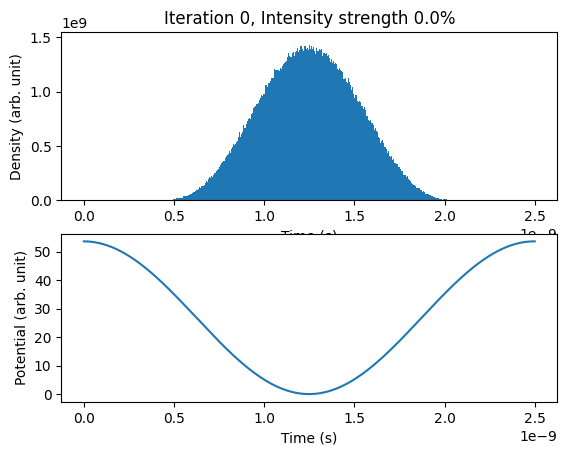

In [4]:
sim.prepare_beam(
    beam=beam1,
    preparation_routine=SemiEmpiricMatcher(
        time_limit=(0, 2.5e-9),
        n_macroparticles=1e3 if pytest_is_active else 1e6,
        seed=0,
        maxiter_intensity_effects=0,
        hamilton_to_density_kwargs=dict(
            density_modifier=2.0,  # Controls density profile sharpness
            hamilton_max=40.0,  # Hamiltonian cutoff [eV]
        ),
        animate=True,
    ),
)

Lets have a closer look at the generated distribution.

Text(0.5, 0, 'Energy Offset [eV]')

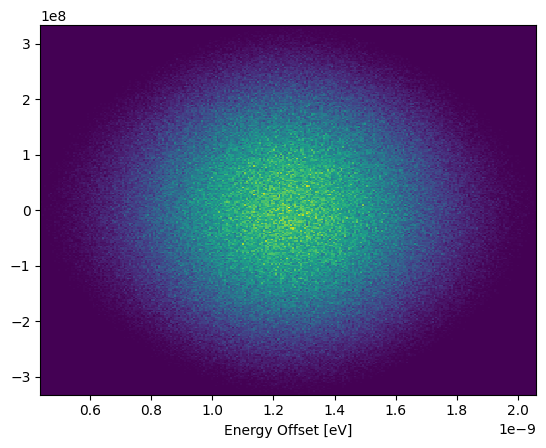

In [5]:
beam1.plot_hist2d()
plt.xlabel("Time [s]")
plt.xlabel("Energy Offset [eV]")

## Preparing the Full Simulation
Before running the simulation, we can define which properties to observe during the simulation.

This will also reserve the memory, and if there are more observations than your computers RAM can hold, it will crash 
at the start of the simulation.

In [6]:
phase_observation = RFStationPhaseObservation(
    each_turn_i=1,
    rf_station=rf_station,
)
bunch_observation = BeamObservationOncePerTurn(each_turn_i=int(1e3 - 1))

Let's offset the matched beam from its stable position to make the results of this simulation more illustrative.

In [7]:
beam1._dt.array_local += 0.25e-9

## Run the Simulation

We have defined the beam physics, what to observe, and our beam. Lets execute the simulation.

In [8]:
if not pytest_is_active:
    backend.set_specials("numba")

sim.run_simulation(
    beams=(beam1,),
    n_turns=N_TURNS,
    observe=(phase_observation, bunch_observation),
)

Set special to `numba`

Beam 0 has 1.00M macroparticles 24.00MB
n_turns=1000
n_elements=2


BLonD3 mainloop: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 284.33it/s, 2.805312ns per particle]


## Analyze the Results
After running the simulation, we can use the observations to analyze the beam dynamics results.

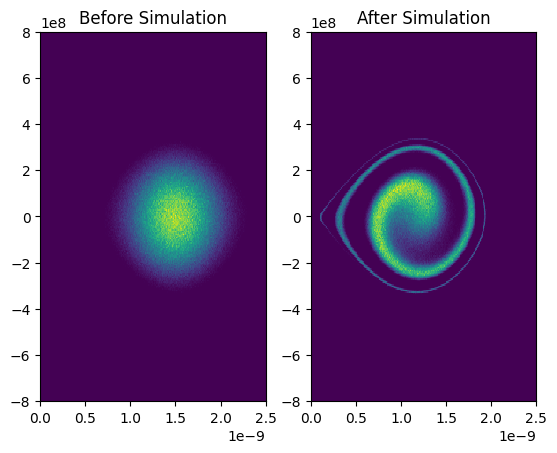

In [9]:
plt.figure()
ax = plt.subplot(1, 2, 1)
plt.title("Before Simulation")
plt.hist2d(
    bunch_observation.dts[0, :],
    bunch_observation.dEs[0, :],
    bins=256,
    range=[[0, 2.5e-9], [-8e8, 8e8]],
)
plt.subplot(1, 2, 2, sharex=ax)
plt.title("After Simulation")
plt.hist2d(
    bunch_observation.dts[-1, :],
    bunch_observation.dEs[-1, :],
    bins=256,
    range=[[0, 2.5e-9], [-8e8, 8e8]],
)

plt.show()